In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100, VOCDetection
from torchvision.models.detection import fasterrcnn_resnet50_fpn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import os
import csv
import json
from tqdm import tqdm
import random
from collections import defaultdict


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
print("Часть A: Загрузка датасета CIFAR100")

# Определение преобразований
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                         std=[0.2675, 0.2565, 0.2761])
])

aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                         std=[0.2675, 0.2565, 0.2761])
])

resize_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Загрузка датасета
train_dataset_full = CIFAR100(root='./data', train=True, download=True, transform=basic_transform)
test_dataset = CIFAR100(root='./data', train=False, download=True, transform=basic_transform)

# Разделение train на train и validation (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

print(f"Обучающая выборка: {len(train_dataset)}")
print(f"Валидационная выборка: {len(val_dataset)}")
print(f"Тестовая выборка: {len(test_dataset)}")
print(f"Количество классов: {len(train_dataset_full.classes)}")

# Для C1: базовое преобразование
train_dataset_c1 = train_dataset
val_dataset_c1 = val_dataset

# Для C2: аугментированное преобразование
train_dataset_c2 = CIFAR100(root='./data', train=True, download=True, transform=aug_transform)
train_dataset_c2, _ = random_split(train_dataset_c2, [train_size, val_size])

# Для C3 и C4: преобразование с изменением размера для ResNet
train_dataset_resize = CIFAR100(root='./data', train=True, download=True, transform=resize_transform)
train_dataset_resize, _ = random_split(train_dataset_resize, [train_size, val_size])
val_dataset_resize = CIFAR100(root='./data', train=False, download=True, transform=resize_transform)

Часть A: Загрузка датасета CIFAR100


D:\Projects\2 course\AI-digital\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Обучающая выборка: 40000
Валидационная выборка: 10000
Тестовая выборка: 10000
Количество классов: 100


Примеры изображений из CIFAR100:


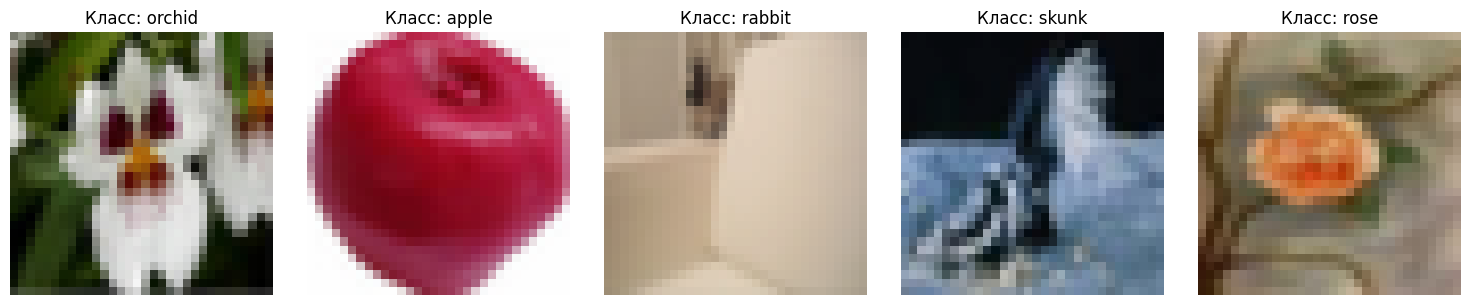


Форма батча: torch.Size([32, 3, 32, 32])
Форма меток: torch.Size([32])
Размер батча: 32


In [3]:
def show_samples(dataset, num_samples=5):
    """Отображение примеров изображений из датасета"""
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for idx, ax in enumerate(axes):
        img, label = dataset[indices[idx]]
        img = img.numpy().transpose(1, 2, 0)
        # Денормализация для визуализации
        mean = np.array([0.5071, 0.4867, 0.4408])
        std = np.array([0.2675, 0.2565, 0.2761])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        ax.imshow(img)
        ax.set_title(f'Класс: {train_dataset_full.classes[label]}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


print("Примеры изображений из CIFAR100:")
show_samples(train_dataset, num_samples=5)

# Проверка DataLoader
sample_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
sample_batch = next(iter(sample_loader))
print(f"\nФорма батча: {sample_batch[0].shape}")
print(f"Форма меток: {sample_batch[1].shape}")
print(f"Размер батча: {sample_batch[0].size(0)}")

Визуализация аугментаций


D:\Projects\2 course\AI-digital\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


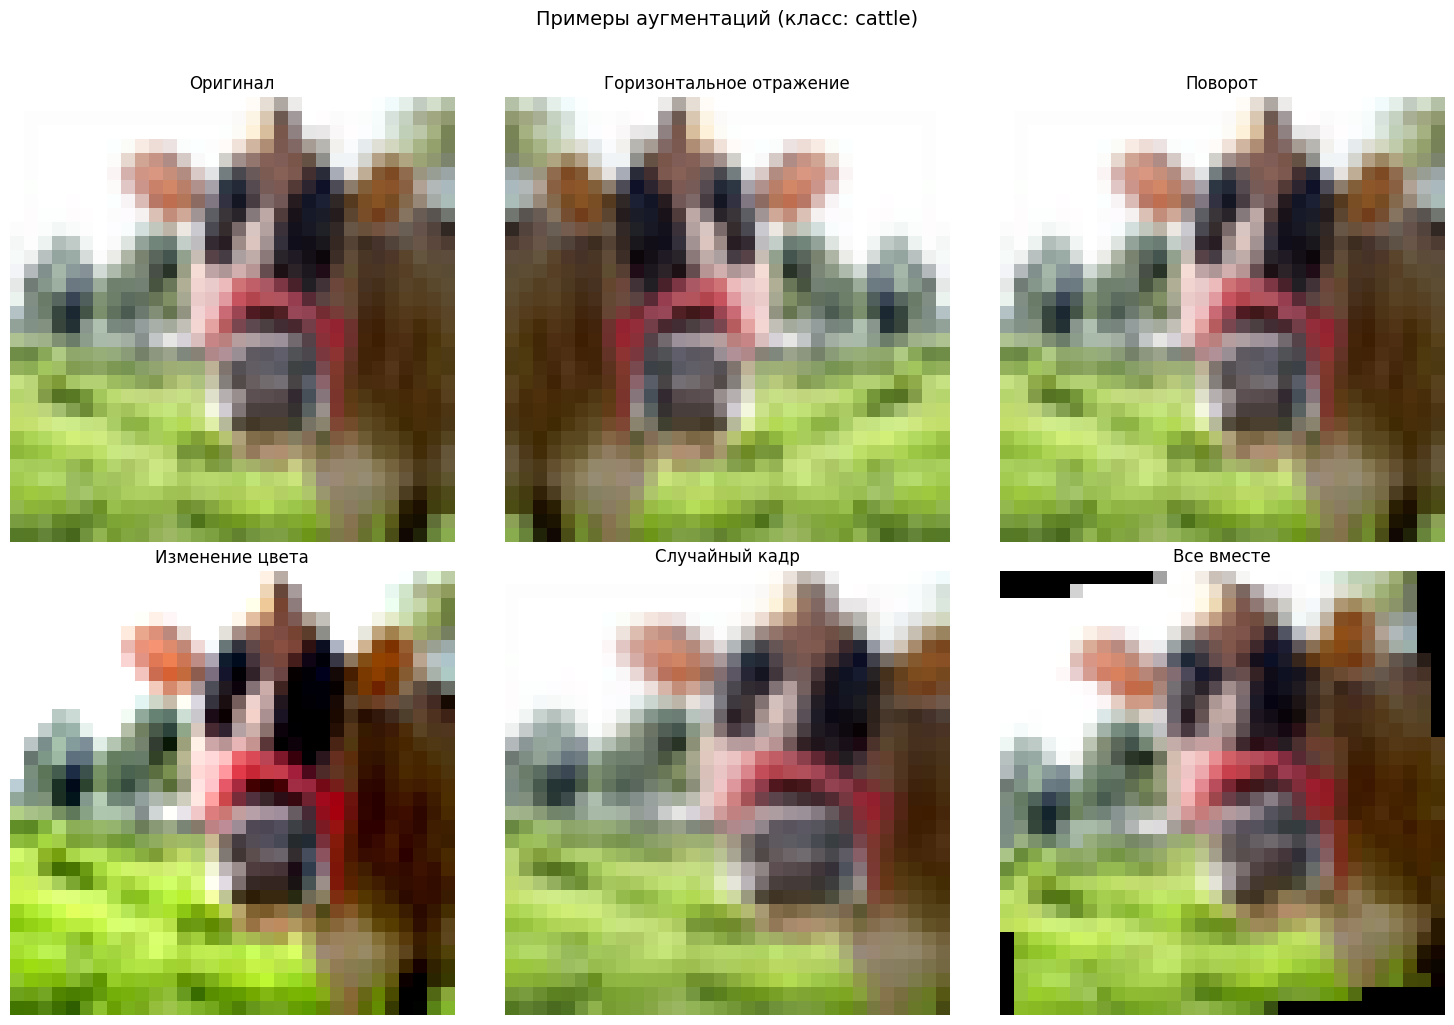

In [27]:
print("Визуализация аугментаций")

# Загружаем одно изображение для демонстрации
demo_dataset = CIFAR100(root='./data', train=True, download=True, transform=None)
sample_img, sample_label = demo_dataset[0]

# Определяем различные аугментации
augmentations = {
    'Оригинал': transforms.Compose([transforms.ToTensor()]),
    'Горизонтальное отражение': transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor()
    ]),
    'Поворот': transforms.Compose([
        transforms.RandomRotation(15),
        transforms.ToTensor()
    ]),
    'Изменение цвета': transforms.Compose([
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        transforms.ToTensor()
    ]),
    'Случайный кадр': transforms.Compose([
        transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
        transforms.ToTensor()
    ]),
    'Все вместе': transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
        transforms.ToTensor()
    ])
}

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (aug_name, aug_transform) in enumerate(augmentations.items()):
    # Применяем аугментацию
    aug_img = aug_transform(sample_img)
    aug_img = aug_img.numpy().transpose(1, 2, 0)
    
    # Нормализуем для отображения
    aug_img = (aug_img - aug_img.min()) / (aug_img.max() - aug_img.min())
    
    axes[idx].imshow(aug_img)
    axes[idx].set_title(aug_name, fontsize=12)
    axes[idx].axis('off')

plt.suptitle(f'Примеры аугментаций (класс: {demo_dataset.classes[sample_label]})', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [4]:
class SimpleCNN(nn.Module):
    """Простая сверточная нейронная сеть для классификации"""

    def __init__(self, num_classes=100):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [5]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    """Обучение модели на одну эпоху"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(dataloader, desc="Обучение"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(dataloader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """Оценка модели на валидационной/тестовой выборке"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Оценка"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(dataloader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

In [6]:
print("Эксперимент C1: Простая CNN без аугментации")

# Создание DataLoader
train_loader_c1 = DataLoader(train_dataset_c1, batch_size=64, shuffle=True)
val_loader_c1 = DataLoader(val_dataset_c1, batch_size=64, shuffle=False)

# Инициализация модели
model_c1 = SimpleCNN(num_classes=100).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=0.001)

# Цикл обучения
num_epochs = 10
train_losses_c1, train_accs_c1 = [], []
val_losses_c1, val_accs_c1 = [], []

best_val_acc = 0
best_model_state = None

for epoch in range(num_epochs):
    print(f"\nЭпоха {epoch + 1}/{num_epochs}")
    train_loss, train_acc = train_one_epoch(model_c1, train_loader_c1, optimizer_c1, criterion, device)
    val_loss, val_acc = evaluate(model_c1, val_loader_c1, criterion, device)

    train_losses_c1.append(train_loss)
    train_accs_c1.append(train_acc)
    val_losses_c1.append(val_loss)
    val_accs_c1.append(val_acc)

    print(f"Потери на обучении: {train_loss:.4f}, Точность на обучении: {train_acc:.2f}%")
    print(f"Потери на валидации: {val_loss:.4f}, Точность на валидации: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_c1.state_dict().copy()

print(f"\nЛучшая точность на валидации для C1: {best_val_acc:.2f}%")

Эксперимент C1: Простая CNN без аугментации

Эпоха 1/10


Оценка: 100%|██████████| 157/157 [00:03<00:00, 43.90it/s]


Потери на обучении: 3.9096, Точность на обучении: 9.95%
Потери на валидации: 3.3733, Точность на валидации: 18.49%

Эпоха 2/10


Оценка: 100%|██████████| 157/157 [00:03<00:00, 42.31it/s]


Потери на обучении: 3.2425, Точность на обучении: 20.56%
Потери на валидации: 2.9006, Точность на валидации: 28.56%

Эпоха 3/10


...

Потери на обучении: 2.0433, Точность на обучении: 44.70%
Потери на валидации: 2.2376, Точность на валидации: 41.80%

Эпоха 9/10


Оценка: 100%|██████████| 157/157 [00:04<00:00, 38.73it/s]


Потери на обучении: 1.9281, Точность на обучении: 47.23%
Потери на валидации: 2.2204, Точность на валидации: 42.42%

Эпоха 10/10


Оценка: 100%|██████████| 157/157 [00:03<00:00, 42.16it/s]

Потери на обучении: 1.8272, Точность на обучении: 49.28%
Потери на валидации: 2.2112, Точность на валидации: 42.61%

Лучшая точность на валидации для C1: 42.61%


In [7]:
print("Эксперимент C2: Простая CNN с аугментацией")

# Создание DataLoader с аугментированными данными
train_loader_c2 = DataLoader(train_dataset_c2, batch_size=64, shuffle=True)

# Инициализация модели
model_c2 = SimpleCNN(num_classes=100).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=0.001)

# Цикл обучения
train_losses_c2, train_accs_c2 = [], []
val_losses_c2, val_accs_c2 = [], []
best_val_acc_c2 = 0
best_model_state_c2 = None

for epoch in range(num_epochs):
    print(f"\nЭпоха {epoch + 1}/{num_epochs}")
    train_loss, train_acc = train_one_epoch(model_c2, train_loader_c2, optimizer_c2, criterion, device)
    val_loss, val_acc = evaluate(model_c2, val_loader_c1, criterion, device)

    train_losses_c2.append(train_loss)
    train_accs_c2.append(train_acc)
    val_losses_c2.append(val_loss)
    val_accs_c2.append(val_acc)

    print(f"Потери на обучении: {train_loss:.4f}, Точность на обучении: {train_acc:.2f}%")
    print(f"Потери на валидации: {val_loss:.4f}, Точность на валидации: {val_acc:.2f}%")

    if val_acc > best_val_acc_c2:
        best_val_acc_c2 = val_acc
        best_model_state_c2 = model_c2.state_dict().copy()

print(f"\nЛучшая точность на валидации для C2: {best_val_acc_c2:.2f}%")

Эксперимент C2: Простая CNN с аугментацией

Эпоха 1/10


Оценка: 100%|██████████| 157/157 [00:03<00:00, 40.20it/s]


Потери на обучении: 3.9924, Точность на обучении: 8.65%
Потери на валидации: 3.3650, Точность на валидации: 19.61%

Эпоха 2/10


Оценка: 100%|██████████| 157/157 [00:03<00:00, 39.49it/s]


Потери на обучении: 3.4281, Точность на обучении: 17.62%
Потери на валидации: 2.9472, Точность на валидации: 26.32%

Эпоха 3/10


...

Потери на обучении: 2.6646, Точность на обучении: 32.05%
Потери на валидации: 2.1977, Точность на валидации: 42.73%

Эпоха 9/10


Оценка: 100%|██████████| 157/157 [00:03<00:00, 40.28it/s]


Потери на обучении: 2.6164, Точность на обучении: 33.37%
Потери на валидации: 2.1388, Точность на валидации: 44.13%

Эпоха 10/10


Оценка: 100%|██████████| 157/157 [00:03<00:00, 40.75it/s]

Потери на обучении: 2.5693, Точность на обучении: 34.15%
Потери на валидации: 2.0466, Точность на валидации: 45.21%

Лучшая точность на валидации для C2: 45.21%


In [8]:
print("Эксперимент C3: ResNet18, обучается только голова (backbone заморожен)")

# Загрузка предобученной ResNet18
model_c3 = torchvision.models.resnet18(pretrained=True)

# Заморозка всех слоев backbone
for param in model_c3.parameters():
    param.requires_grad = False

# Замена классификационной головы
num_features = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_features, 100)
model_c3 = model_c3.to(device)

# Создание DataLoader с изменением размера
train_dataset_c3 = CIFAR100(root='./data', train=True, download=True, transform=resize_transform)
val_dataset_c3 = CIFAR100(root='./data', train=False, download=True, transform=resize_transform)

# Разделение обучающей выборки
train_size = int(0.8 * len(train_dataset_c3))
val_size = len(train_dataset_c3) - train_size
train_dataset_c3, _ = random_split(train_dataset_c3, [train_size, val_size])

train_loader_c3 = DataLoader(train_dataset_c3, batch_size=32, shuffle=True)
val_loader_c3 = DataLoader(val_dataset_c3, batch_size=32, shuffle=False)

# Оптимизация только головы классификатора
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=0.001)

# Цикл обучения
train_losses_c3, train_accs_c3 = [], []
val_losses_c3, val_accs_c3 = [], []
best_val_acc_c3 = 0
best_model_state_c3 = None

for epoch in range(num_epochs):
    print(f"\nЭпоха {epoch+1}/{num_epochs}")
    train_loss, train_acc = train_one_epoch(model_c3, train_loader_c3, optimizer_c3, criterion, device)
    val_loss, val_acc = evaluate(model_c3, val_loader_c3, criterion, device)
    
    train_losses_c3.append(train_loss)
    train_accs_c3.append(train_acc)
    val_losses_c3.append(val_loss)
    val_accs_c3.append(val_acc)
    
    print(f"Потери на обучении: {train_loss:.4f}, Точность на обучении: {train_acc:.2f}%")
    print(f"Потери на валидации: {val_loss:.4f}, Точность на валидации: {val_acc:.2f}%")
    
    if val_acc > best_val_acc_c3:
        best_val_acc_c3 = val_acc
        best_model_state_c3 = model_c3.state_dict().copy()

print(f"\nЛучшая точность на валидации для C3: {best_val_acc_c3:.2f}%")

Эксперимент C3: ResNet18, обучается только голова (backbone заморожен)


D:\Projects\2 course\AI-digital\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Projects\2 course\AI-digital\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Эпоха 1/10


Оценка: 100%|██████████| 313/313 [03:03<00:00,  1.71it/s]


Потери на обучении: 2.7094, Точность на обучении: 34.69%
Потери на валидации: 2.0360, Точность на валидации: 46.92%

Эпоха 2/10


...

Потери на обучении: 1.7000, Точность на обучении: 53.59%
Потери на валидации: 1.7352, Точность на валидации: 53.60%

Эпоха 9/10


Оценка: 100%|██████████| 313/313 [04:01<00:00,  1.30it/s]


Потери на обучении: 1.6854, Точность на обучении: 54.15%
Потери на валидации: 1.7413, Точность на валидации: 53.83%

Эпоха 10/10


Оценка: 100%|██████████| 313/313 [03:47<00:00,  1.38it/s]

Потери на обучении: 1.6781, Точность на обучении: 54.26%
Потери на валидации: 1.7357, Точность на валидации: 53.35%

Лучшая точность на валидации для C3: 53.83%


In [9]:
print("Эксперимент C4: ResNet18 с дообучением (layer4 + голова)")

# Загрузка предобученной ResNet18
model_c4 = torchvision.models.resnet18(pretrained=True)

# Заморозка всех слоев
for param in model_c4.parameters():
    param.requires_grad = False

# Разморозка layer4 и головы
for param in model_c4.layer4.parameters():
    param.requires_grad = True

# Замена классификационной головы
num_features = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_features, 100)
model_c4 = model_c4.to(device)

# Оптимизация layer4 и головы с разными learning rates
optimizer_c4 = optim.Adam([
    {'params': model_c4.layer4.parameters(), 'lr': 0.0001},
    {'params': model_c4.fc.parameters(), 'lr': 0.001}
])

# Цикл обучения
train_losses_c4, train_accs_c4 = [], []
val_losses_c4, val_accs_c4 = [], []
best_val_acc_c4 = 0
best_model_state_c4 = None

for epoch in range(num_epochs):
    print(f"\nЭпоха {epoch + 1}/{num_epochs}")
    train_loss, train_acc = train_one_epoch(model_c4, train_loader_c3, optimizer_c4, criterion, device)
    val_loss, val_acc = evaluate(model_c4, val_loader_c3, criterion, device)

    train_losses_c4.append(train_loss)
    train_accs_c4.append(train_acc)
    val_losses_c4.append(val_loss)
    val_accs_c4.append(val_acc)

    print(f"Потери на обучении: {train_loss:.4f}, Точность на обучении: {train_acc:.2f}%")
    print(f"Потери на валидации: {val_loss:.4f}, Точность на валидации: {val_acc:.2f}%")

    if val_acc > best_val_acc_c4:
        best_val_acc_c4 = val_acc
        best_model_state_c4 = model_c4.state_dict().copy()

print(f"\nЛучшая точность на валидации для C4: {best_val_acc_c4:.2f}%")

Эксперимент C4: ResNet18 с дообучением (layer4 + голова)

Эпоха 1/10


Оценка: 100%|██████████| 313/313 [03:29<00:00,  1.49it/s]


Потери на обучении: 1.7914, Точность на обучении: 51.81%
Потери на валидации: 1.2553, Точность на валидации: 63.65%

Эпоха 2/10


Оценка: 100%|██████████| 313/313 [03:51<00:00,  1.35it/s]


Потери на обучении: 1.1273, Точность на обучении: 67.00%
Потери на валидации: 1.1453, Точность на валидации: 67.30%

Эпоха 3/10


...

Потери на обучении: 0.4634, Точность на обучении: 85.24%
Потери на валидации: 1.1605, Точность на валидации: 71.75%

Эпоха 9/10


Оценка: 100%|██████████| 313/313 [03:52<00:00,  1.35it/s]


Потери на обучении: 0.4178, Точность на обучении: 86.71%
Потери на валидации: 1.1767, Точность на валидации: 72.08%

Эпоха 10/10


Оценка: 100%|██████████| 313/313 [03:19<00:00,  1.57it/s]

Потери на обучении: 0.3819, Точность на обучении: 87.63%
Потери на валидации: 1.3007, Точность на валидации: 70.16%

Лучшая точность на валидации для C4: 72.08%


In [10]:
print("Сравнение всех экспериментов")

experiments = {
    'C1': best_val_acc,
    'C2': best_val_acc_c2,
    'C3': best_val_acc_c3,
    'C4': best_val_acc_c4
}

# Поиск лучшей модели
best_exp = max(experiments, key=experiments.get)
print(f"\nЛучшие точности на валидации:")
for exp, acc in experiments.items():
    print(f"{exp}: {acc:.2f}%")
print(f"\nЛучший эксперимент: {best_exp} с точностью {experiments[best_exp]:.2f}%")

# Оценка лучшей модели на тестовой выборке
print(f"\nОценка лучшей модели ({best_exp}) на тестовой выборке...")

# Подготовка тестового DataLoader с соответствующими преобразованиями
if best_exp in ['C3', 'C4']:
    test_dataset_resized = CIFAR100(root='./data', train=False, download=True, transform=resize_transform)
    test_loader_final = DataLoader(test_dataset_resized, batch_size=32, shuffle=False)
else:
    test_loader_final = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Загрузка лучшей модели
if best_exp == 'C1':
    best_model = SimpleCNN(num_classes=100).to(device)
    best_model.load_state_dict(best_model_state)
elif best_exp == 'C2':
    best_model = SimpleCNN(num_classes=100).to(device)
    best_model.load_state_dict(best_model_state_c2)
elif best_exp == 'C3':
    best_model = torchvision.models.resnet18(pretrained=True)
    num_features = best_model.fc.in_features
    best_model.fc = nn.Linear(num_features, 100)
    best_model.load_state_dict(best_model_state_c3)
    best_model = best_model.to(device)
else:
    best_model = torchvision.models.resnet18(pretrained=True)
    num_features = best_model.fc.in_features
    best_model.fc = nn.Linear(num_features, 100)
    best_model.load_state_dict(best_model_state_c4)
    best_model = best_model.to(device)

test_loss, test_acc = evaluate(best_model, test_loader_final, criterion, device)
print(f"Точность на тестовой выборке для {best_exp}: {test_acc:.2f}%")

Сравнение всех экспериментов

Лучшие точности на валидации:
C1: 42.61%
C2: 45.21%
C3: 53.83%
C4: 72.08%

Лучший эксперимент: C4 с точностью 72.08%

Оценка лучшей модели (C4) на тестовой выборке...


Оценка: 100%|██████████| 313/313 [03:46<00:00,  1.38it/s]

Точность на тестовой выборке для C4: 70.37%


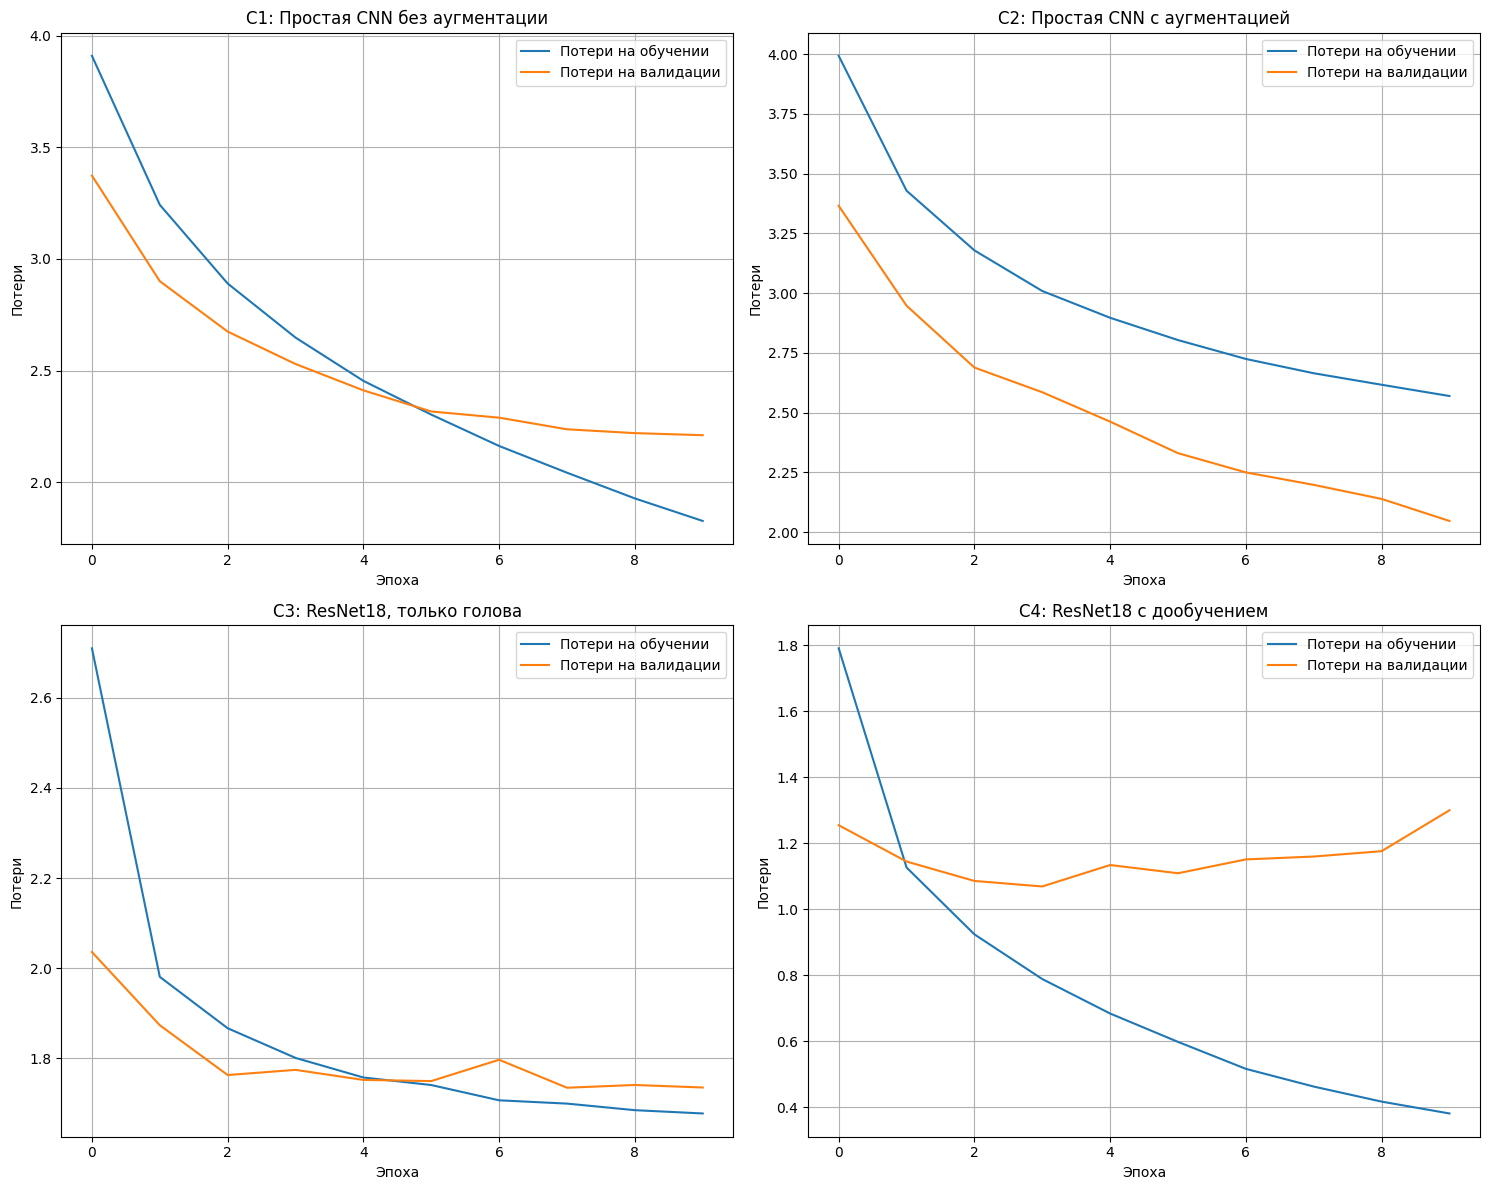

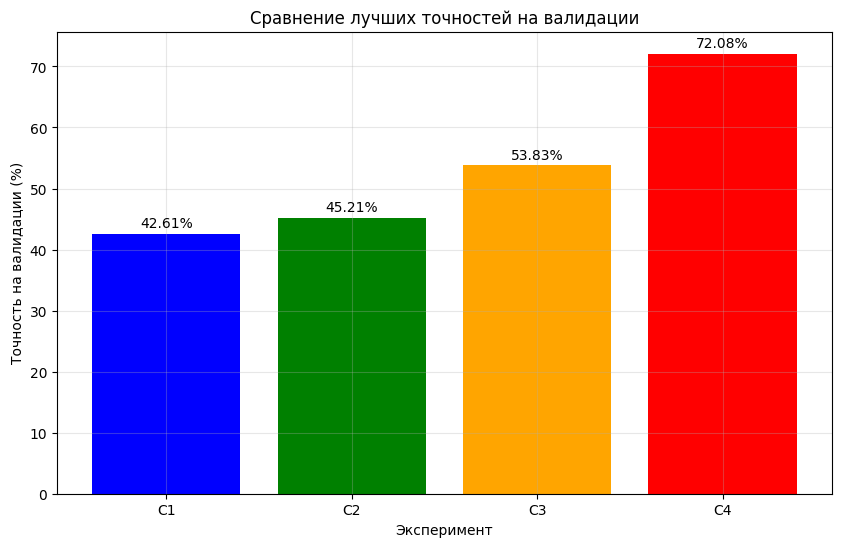

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# График C1
axes[0, 0].plot(train_losses_c1, label='Потери на обучении')
axes[0, 0].plot(val_losses_c1, label='Потери на валидации')
axes[0, 0].set_title('C1: Простая CNN без аугментации')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Потери')
axes[0, 0].legend()
axes[0, 0].grid(True)

# График C2
axes[0, 1].plot(train_losses_c2, label='Потери на обучении')
axes[0, 1].plot(val_losses_c2, label='Потери на валидации')
axes[0, 1].set_title('C2: Простая CNN с аугментацией')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Потери')
axes[0, 1].legend()
axes[0, 1].grid(True)

# График C3
axes[1, 0].plot(train_losses_c3, label='Потери на обучении')
axes[1, 0].plot(val_losses_c3, label='Потери на валидации')
axes[1, 0].set_title('C3: ResNet18, только голова')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Потери')
axes[1, 0].legend()
axes[1, 0].grid(True)

# График C4
axes[1, 1].plot(train_losses_c4, label='Потери на обучении')
axes[1, 1].plot(val_losses_c4, label='Потери на валидации')
axes[1, 1].set_title('C4: ResNet18 с дообучением')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Потери')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=100)
plt.show()

# Сравнительная столбчатая диаграмма
plt.figure(figsize=(10, 6))
exp_names = list(experiments.keys())
exp_values = list(experiments.values())
bars = plt.bar(exp_names, exp_values, color=['blue', 'green', 'orange', 'red'])
plt.title('Сравнение лучших точностей на валидации')
plt.xlabel('Эксперимент')
plt.ylabel('Точность на валидации (%)')
plt.grid(True, alpha=0.3)

# Добавление значений на столбцы
for bar, value in zip(bars, exp_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{value:.2f}%', ha='center', va='bottom')

plt.savefig('artifacts/figures/classification_compare.png', dpi=100)
plt.show()

In [12]:
print("Часть B: Детекция объектов на Pascal VOC")

# Загрузка датасета Pascal VOC
voc_train = VOCDetection(root='./data', year='2012', image_set='train', download=True)
voc_val = VOCDetection(root='./data', year='2012', image_set='val', download=True)

print(f"Обучающая выборка: {len(voc_train)}")
print(f"Валидационная выборка: {len(voc_val)}")

# Загрузка предобученной модели Faster R-CNN
detection_model = fasterrcnn_resnet50_fpn(pretrained=True)
detection_model = detection_model.to(device)
detection_model.eval()

print("Модель Faster R-CNN успешно загружена!")

Часть B: Детекция объектов на Pascal VOC


100%|██████████| 2.00G/2.00G [24:23<00:00, 1.37MB/s]  


Обучающая выборка: 5717
Валидационная выборка: 5823


D:\Projects\2 course\AI-digital\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\ksolo/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:29<00:00, 5.74MB/s] 


Модель Faster R-CNN успешно загружена!


In [21]:
def get_voc_categories():
    """Категории объектов VOC (индексы с 1 по 20)"""
    categories = {
        1: 'aeroplane', 2: 'bicycle', 3: 'bird', 4: 'boat', 5: 'bottle',
        6: 'bus', 7: 'car', 8: 'cat', 9: 'chair', 10: 'cow',
        11: 'diningtable', 12: 'dog', 13: 'horse', 14: 'motorbike', 15: 'person',
        16: 'pottedplant', 17: 'sheep', 18: 'sofa', 19: 'train', 20: 'tvmonitor'
    }
    return categories

def get_category_name(label_id):
    """Получение имени категории по ID с проверкой"""
    categories = get_voc_categories()
    # Проверяем, что label_id находится в допустимом диапазоне
    if label_id in categories:
        return categories[label_id]
    else:
        return f'class_{label_id}'  # Возвращаем общее имя для неизвестных классов

def parse_voc_annotation(annotation):
    """Разбор XML аннотации VOC для извлечения ограничивающих рамок и меток"""
    objects = annotation['annotation']['object']
    if not isinstance(objects, list):
        objects = [objects]
    
    boxes = []
    labels = []
    label_ids = []  # Сохраняем ID меток для сопоставления
    
    # Создаем словарь для преобразования названий в ID
    voc_categories = get_voc_categories()
    name_to_id = {name: idx for idx, name in voc_categories.items()}
    
    for obj in objects:
        bbox = obj['bndbox']
        box = [
            float(bbox['xmin']),
            float(bbox['ymin']),
            float(bbox['xmax']),
            float(bbox['ymax'])
        ]
        boxes.append(box)
        label_name = obj['name']
        labels.append(label_name)
        # Получаем ID метки для сопоставления
        label_ids.append(name_to_id.get(label_name, 0))
    
    return boxes, labels, label_ids

def compute_iou(box1, box2):
    """Вычисление IoU между двумя рамками"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

def match_predictions(predictions, ground_truths, iou_threshold=0.5):
    """Сопоставление предсказаний с истинными рамками на основе IoU"""
    matches = []
    matched_gt = set()
    
    for pred in predictions:
        best_iou = 0
        best_gt_idx = -1
        
        for idx, gt in enumerate(ground_truths):
            if idx in matched_gt:
                continue
            # Сравниваем по ID меток
            if pred['label_id'] != gt['label_id']:
                continue
            iou = compute_iou(pred['box'], gt['box'])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = idx
        
        if best_iou >= iou_threshold:
            matches.append({
                'pred': pred,
                'gt': ground_truths[best_gt_idx],
                'iou': best_iou
            })
            matched_gt.add(best_gt_idx)
    
    return matches, matched_gt

def calculate_metrics(predictions, ground_truths, iou_threshold=0.5):
    """Вычисление precision, recall и среднего IoU"""
    matches, matched_gt = match_predictions(predictions, ground_truths, iou_threshold)
    
    tp = len(matches)
    fp = len(predictions) - tp
    fn = len(ground_truths) - len(matched_gt)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    mean_iou = np.mean([m['iou'] for m in matches]) if matches else 0
    
    return precision, recall, mean_iou

In [22]:
def visualize_detections(image, predictions, ground_truths=None, title="Детекции", score_threshold=0.5):
    """Визуализация детекций с ограничивающими рамками"""
    img = image.copy()
    draw = ImageDraw.Draw(img)
    
    # Отрисовка истинных рамок зеленым цветом
    if ground_truths:
        for gt in ground_truths:
            box = gt['box']
            draw.rectangle(box, outline='green', width=2)
            draw.text((box[0], box[1]-15), f"GT: {gt['label']}", fill='green')
    
    # Отрисовка предсказанных рамок красным цветом
    for pred in predictions:
        if pred['score'] >= score_threshold:
            box = pred['box']
            draw.rectangle(box, outline='red', width=2)
            draw.text((box[0], box[1]-15), f"{pred['label']}: {pred['score']:.2f}", fill='red')
    
    return img

def run_detection_inference(model, dataset, num_samples=5, score_threshold=0.3):
    """Запуск инференса детекции на примерах"""
    model.eval()
    results = []
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for idx in indices:
            image, target = dataset[idx]
            
            # Преобразование PIL изображения в тензор
            img_tensor = transforms.ToTensor()(image).unsqueeze(0).to(device)
            
            # Запуск инференса
            predictions = model(img_tensor)[0]
            
            # Разбор истинных аннотаций
            gt_boxes, gt_labels, gt_label_ids = parse_voc_annotation(target)
            ground_truths = [
                {'box': box, 'label': label, 'label_id': label_id}
                for box, label, label_id in zip(gt_boxes, gt_labels, gt_label_ids)
            ]
            
            # Разбор предсказаний
            pred_boxes = predictions['boxes'].cpu().numpy()
            pred_scores = predictions['scores'].cpu().numpy()
            pred_labels = predictions['labels'].cpu().numpy()
            
            preds = []
            for box, score, label_id in zip(pred_boxes, pred_scores, pred_labels):
                if score >= score_threshold:
                    # Получаем имя категории с проверкой
                    category_name = get_category_name(label_id)
                    preds.append({
                        'box': box.tolist(),
                        'score': float(score),
                        'label': category_name,
                        'label_id': int(label_id)
                    })
            
            # Вычисление метрик
            precision, recall, mean_iou = calculate_metrics(preds, ground_truths)
            
            results.append({
                'image': image,
                'predictions': preds,
                'ground_truths': ground_truths,
                'precision': precision,
                'recall': recall,
                'mean_iou': mean_iou,
                'num_preds': len(preds),
                'num_gt': len(ground_truths)
            })
    
    return results

V1: Инференс детекции с порогом уверенности = 0.3
Средняя точность (Precision): 0.000
Средняя полнота (Recall): 0.000
Средний IoU: 0.000


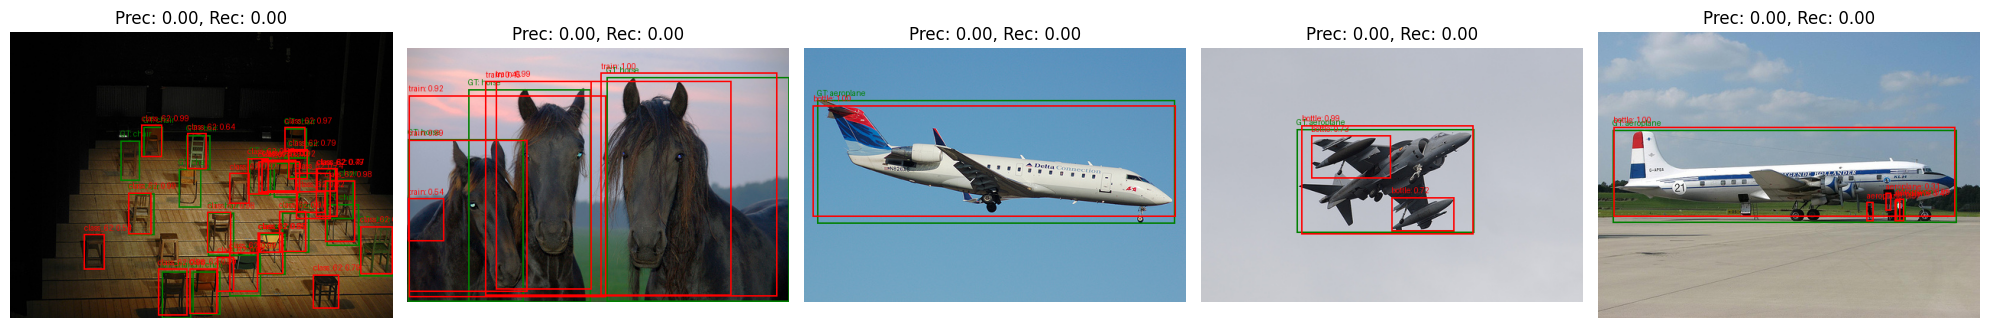

In [23]:
print("V1: Инференс детекции с порогом уверенности = 0.3")

v1_results = run_detection_inference(detection_model, voc_val, num_samples=5, score_threshold=0.3)

# Вычисление агрегированных метрик
v1_precisions = [r['precision'] for r in v1_results]
v1_recalls = [r['recall'] for r in v1_results]
v1_ious = [r['mean_iou'] for r in v1_results]

print(f"Средняя точность (Precision): {np.mean(v1_precisions):.3f}")
print(f"Средняя полнота (Recall): {np.mean(v1_recalls):.3f}")
print(f"Средний IoU: {np.mean(v1_ious):.3f}")

# Визуализация результатов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, result in enumerate(v1_results):
    img_with_dets = visualize_detections(
        result['image'].copy(),
        result['predictions'],
        result['ground_truths'],
        f"V1 (порог=0.3) - {result['num_preds']}/{result['num_gt']} рамок",
        score_threshold=0.3
    )
    axes[idx].imshow(img_with_dets)
    axes[idx].axis('off')
    axes[idx].set_title(f"Prec: {result['precision']:.2f}, Rec: {result['recall']:.2f}")

plt.tight_layout()
plt.savefig('artifacts/figures/detection_examples_v1.png', dpi=100)
plt.show()

V2: Инференс детекции с порогом уверенности = 0.7
Средняя точность (Precision): 0.033
Средняя полнота (Recall): 0.067
Средний IoU: 0.190


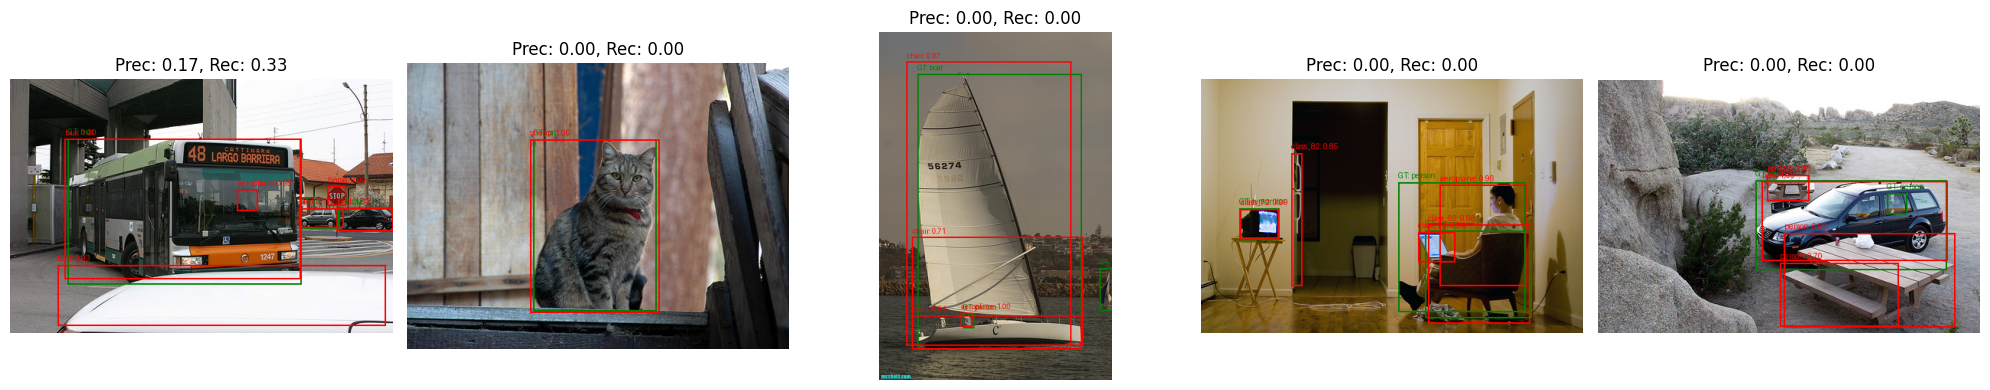

In [24]:
print("V2: Инференс детекции с порогом уверенности = 0.7")

v2_results = run_detection_inference(detection_model, voc_val, num_samples=5, score_threshold=0.7)

# Вычисление агрегированных метрик
v2_precisions = [r['precision'] for r in v2_results]
v2_recalls = [r['recall'] for r in v2_results]
v2_ious = [r['mean_iou'] for r in v2_results]

print(f"Средняя точность (Precision): {np.mean(v2_precisions):.3f}")
print(f"Средняя полнота (Recall): {np.mean(v2_recalls):.3f}")
print(f"Средний IoU: {np.mean(v2_ious):.3f}")

# Визуализация результатов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, result in enumerate(v2_results):
    img_with_dets = visualize_detections(
        result['image'].copy(),
        result['predictions'],
        result['ground_truths'],
        f"V2 (порог=0.7) - {result['num_preds']}/{result['num_gt']} рамок",
        score_threshold=0.7
    )
    axes[idx].imshow(img_with_dets)
    axes[idx].axis('off')
    axes[idx].set_title(f"Prec: {result['precision']:.2f}, Rec: {result['recall']:.2f}")

plt.tight_layout()
plt.savefig('artifacts/figures/detection_examples_v2.png', dpi=100)
plt.show()

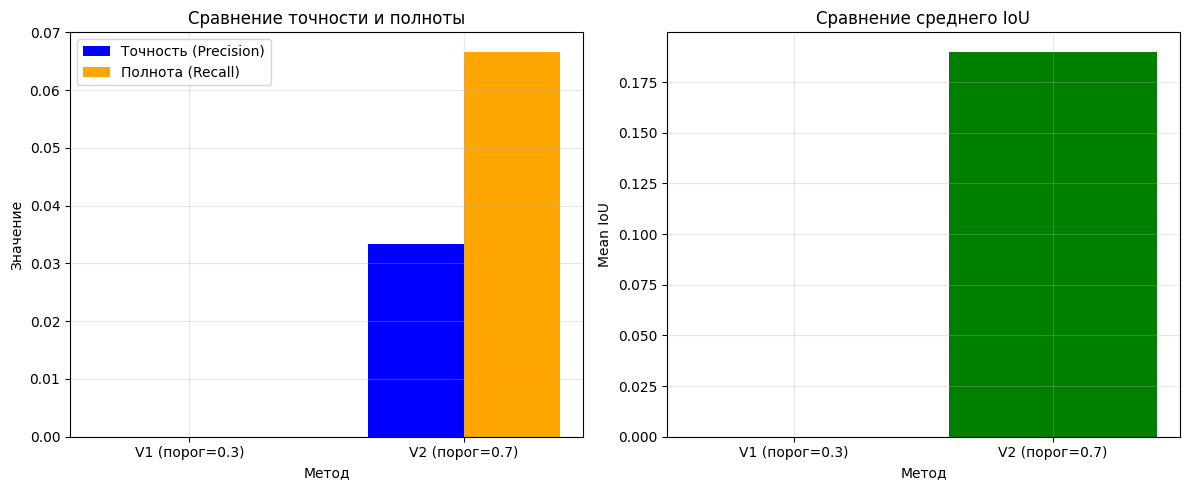


Анализ:
V1 (порог=0.3): Более низкая точность, но более высокая полнота
  - Больше детекций на изображение
  - Выше вероятность обнаружить объекты, но больше ложных срабатываний

V2 (порог=0.7): Более высокая точность, но более низкая полнота
  - Меньше детекций, но они более уверенные
  - Пропускает некоторые объекты, но предсказания более надежны


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Сравнение Precision и Recall
methods = ['V1 (порог=0.3)', 'V2 (порог=0.7)']
precisions = [np.mean(v1_precisions), np.mean(v2_precisions)]
recalls = [np.mean(v1_recalls), np.mean(v2_recalls)]

x = np.arange(len(methods))
width = 0.35

ax1.bar(x - width / 2, precisions, width, label='Точность (Precision)', color='blue')
ax1.bar(x + width / 2, recalls, width, label='Полнота (Recall)', color='orange')
ax1.set_xlabel('Метод')
ax1.set_ylabel('Значение')
ax1.set_title('Сравнение точности и полноты')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Сравнение Mean IoU
ax2.bar(methods, [np.mean(v1_ious), np.mean(v2_ious)], color='green')
ax2.set_xlabel('Метод')
ax2.set_ylabel('Mean IoU')
ax2.set_title('Сравнение среднего IoU')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/detection_metrics.png', dpi=100)
plt.show()

print("\nАнализ:")
print("V1 (порог=0.3): Более низкая точность, но более высокая полнота")
print("  - Больше детекций на изображение")
print("  - Выше вероятность обнаружить объекты, но больше ложных срабатываний")
print("\nV2 (порог=0.7): Более высокая точность, но более низкая полнота")
print("  - Меньше детекций, но они более уверенные")
print("  - Пропускает некоторые объекты, но предсказания более надежны")

In [26]:
print("Сохранение артефактов")

# Сохранение лучшей модели
if best_exp == 'C1':
    torch.save(best_model_state, 'artifacts/best_classifier.pt')
elif best_exp == 'C2':
    torch.save(best_model_state_c2, 'artifacts/best_classifier.pt')
elif best_exp == 'C3':
    torch.save(best_model_state_c3, 'artifacts/best_classifier.pt')
else:
    torch.save(best_model_state_c4, 'artifacts/best_classifier.pt')

print("Модель сохранена: best_classifier.pt")

# Сохранение конфигурации лучшей модели
best_config = {
    'dataset': 'CIFAR100',
    'architecture': best_exp,
    'transforms': 'resize_transform' if best_exp in ['C3', 'C4'] else (
        'aug_transform' if best_exp == 'C2' else 'basic_transform'),
    'batch_size': 32 if best_exp in ['C3', 'C4'] else 64,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'num_epochs': num_epochs,
    'seed': 42,
    'best_val_accuracy': experiments[best_exp],
    'test_accuracy': test_acc
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)

print("Конфигурация сохранена: best_classifier_config.json")

# Сохранение результатов в runs.csv
runs_data = [
    # Эксперименты классификации
    {'experiment_id': 'C1', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': 42,
     'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': num_epochs,
     'best_val_accuracy': best_val_acc, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None,
     'notes': 'Без аугментации'},
    {'experiment_id': 'C2', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': 42,
     'model_summary': 'SimpleCNN', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': num_epochs,
     'best_val_accuracy': best_val_acc_c2, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None,
     'notes': 'С аугментацией'},
    {'experiment_id': 'C3', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': 42,
     'model_summary': 'ResNet18_head_only', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': num_epochs,
     'best_val_accuracy': best_val_acc_c3, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None,
     'notes': 'Backbone заморожен, обучается только голова'},
    {'experiment_id': 'C4', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': 42,
     'model_summary': 'ResNet18_finetune', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': num_epochs,
     'best_val_accuracy': best_val_acc_c4, 'test_accuracy': test_acc, 'precision': None, 'recall': None,
     'mean_iou': None,
     'notes': 'Дообучение layer4 + голова'},
    # Эксперименты детекции
    {'experiment_id': 'V1', 'task': 'detection', 'dataset': 'PascalVOC', 'seed': 42,
     'model_summary': 'FasterRCNN_ResNet50_FPN', 'optimizer': None, 'lr': None, 'epochs_trained': None,
     'best_val_accuracy': None, 'test_accuracy': None, 'precision': np.mean(v1_precisions),
     'recall': np.mean(v1_recalls), 'mean_iou': np.mean(v1_ious),
     'notes': 'Порог уверенности 0.3'},
    {'experiment_id': 'V2', 'task': 'detection', 'dataset': 'PascalVOC', 'seed': 42,
     'model_summary': 'FasterRCNN_ResNet50_FPN', 'optimizer': None, 'lr': None, 'epochs_trained': None,
     'best_val_accuracy': None, 'test_accuracy': None, 'precision': np.mean(v2_precisions),
     'recall': np.mean(v2_recalls), 'mean_iou': np.mean(v2_ious),
     'notes': 'Порог уверенности 0.7'}
]

# Запись в CSV
with open('artifacts/runs.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=runs_data[0].keys())
    writer.writeheader()
    writer.writerows(runs_data)

print("Результаты сохранены: runs.csv")
print("\nВсе артефакты успешно сохранены!")

Сохранение артефактов
Модель сохранена: best_classifier.pt
Конфигурация сохранена: best_classifier_config.json
Результаты сохранены: runs.csv

Все артефакты успешно сохранены!
